### Miembros del Grupo
#### Ivan Nevado Martin
#### Gonzalo de Ramon Murillo 
#### Joseph Egusquiza Cueva

In [1]:
# Instalación de dependencias necesarias (ejecutar una vez)
%pip install -q lightgbm shap

Note: you may need to restart the kernel to use updated packages.


### 1. Introducción y Objetivos

El objetivo de esta práctica es construir, optimizar y auditar un modelo de concesión 
de crédito bajo dos escenarios de coste asimétrico:

- **Escenario 1** (Coste FP = Coste FN = 1): un falso positivo (conceder crédito a un 
  cliente que impagará) y un falso negativo (denegar crédito a un buen pagador) 
  penalizan por igual.
- **Escenario 2** (Coste FP = 1, Coste FN = 10): el impago se penaliza diez veces más 
  que la denegación errónea, reflejando que en la práctica bancaria el coste de un 
  cliente que no paga suele ser muy superior al coste de oportunidad de haber 
  rechazado a un buen cliente.

Para cada escenario comparamos dos enfoques de modelado:

- Un **modelo supervisado estático** (LightGBM calibrado), donde el umbral de decisión 
  se ajusta analíticamente al umbral de Bayes correspondiente a cada relación de costes 
  (1/(1+coste_FN)).
- Un **Multi-Armed Bandit contextual**, que aprende de forma online y solo recibe 
  feedback (la etiqueta real) cuando decide conceder el crédito, simulando la censura 
  de información que ocurre en un entorno de producción real.

Una vez seleccionado el modelo ganador de cada escenario según el coste promedio en 
validación, auditamos su comportamiento con técnicas de XAI para poder responder a la 
pregunta central de esta práctica: si un cliente pide explicaciones sobre por qué se le 
deniega un crédito, ¿qué información le damos? Para ello combinamos:

- Un **modelo subrogado** (árbol de decisión poco profundo) que traduce el comportamiento 
  del modelo caja negra a reglas interpretables.
- **Análisis de contrafactuales** para ejemplos concretos de clase real 0 y 1, que 
  identifican el cambio mínimo y accionable que habría revertido la decisión.
- **Análisis SHAP global y local**, para cuantificar qué variables pesan más en el 
  modelo en general y en cada decisión individual.
- **Partial Dependence Plots**, como técnica complementaria para verificar que las 
  relaciones aprendidas por el modelo tienen sentido de negocio.

El resultado de este análisis debe permitirnos evaluar no solo qué modelo minimiza el 
coste esperado, sino también si su lógica de decisión es transparente, coherente y 
defendible ante un cliente o un regulador.

### 2. Análisis Exploratorio de Datos (EDA) y Preprocesamiento

En esta sección vamos a analizar a fondo las variables de nuestro dataset financiero. Nuestro objetivo es entender la distribución del riesgo, encontrar valores atípicos (outliers) y preparar matemáticamente los datos para que tanto los modelos basados en árboles como los lineales (MAB) puedan procesarlos eficientemente.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
# Configuración visual para gráficos más profesionales
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (10, 6), 'font.size': 12})

# 1. Cargar los datos de construcción (entrenamiento + validación)
# Ajusta la ruta según tus archivos locales de la práctica
df = pd.read_csv('cs_construccion.csv')

# Corrección básica de edad (no pueden haber edades negativas o 0 en créditos)
df.loc[df['age'] <= 18, 'age'] = 18


### 2.1 Análisis de la Variable Objetivo

El primer paso en riesgo de crédito es entender el desequilibrio de clases.

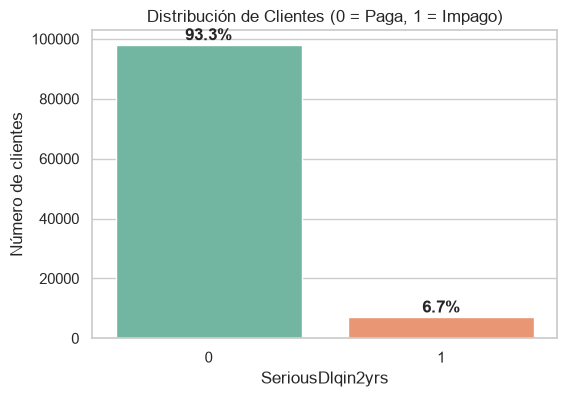

In [3]:
# Gráfico de distribución de impagos
plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, x='SeriousDlqin2yrs', palette='Set2')
plt.title('Distribución de Clientes (0 = Paga, 1 = Impago)')
plt.ylabel('Número de clientes')

# Añadir porcentajes
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%\n'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='center', fontweight='bold')
plt.show()

### 2.2 Distribuciones y Detección de Outliers (Análisis Multivariante)

Vamos a observar las distribuciones de las variables continuas. En el sector financiero, variables como DebtRatio o la utilización de las tarjetas de crédito suelen tener distribuciones de "cola larga" (outliers extremos).

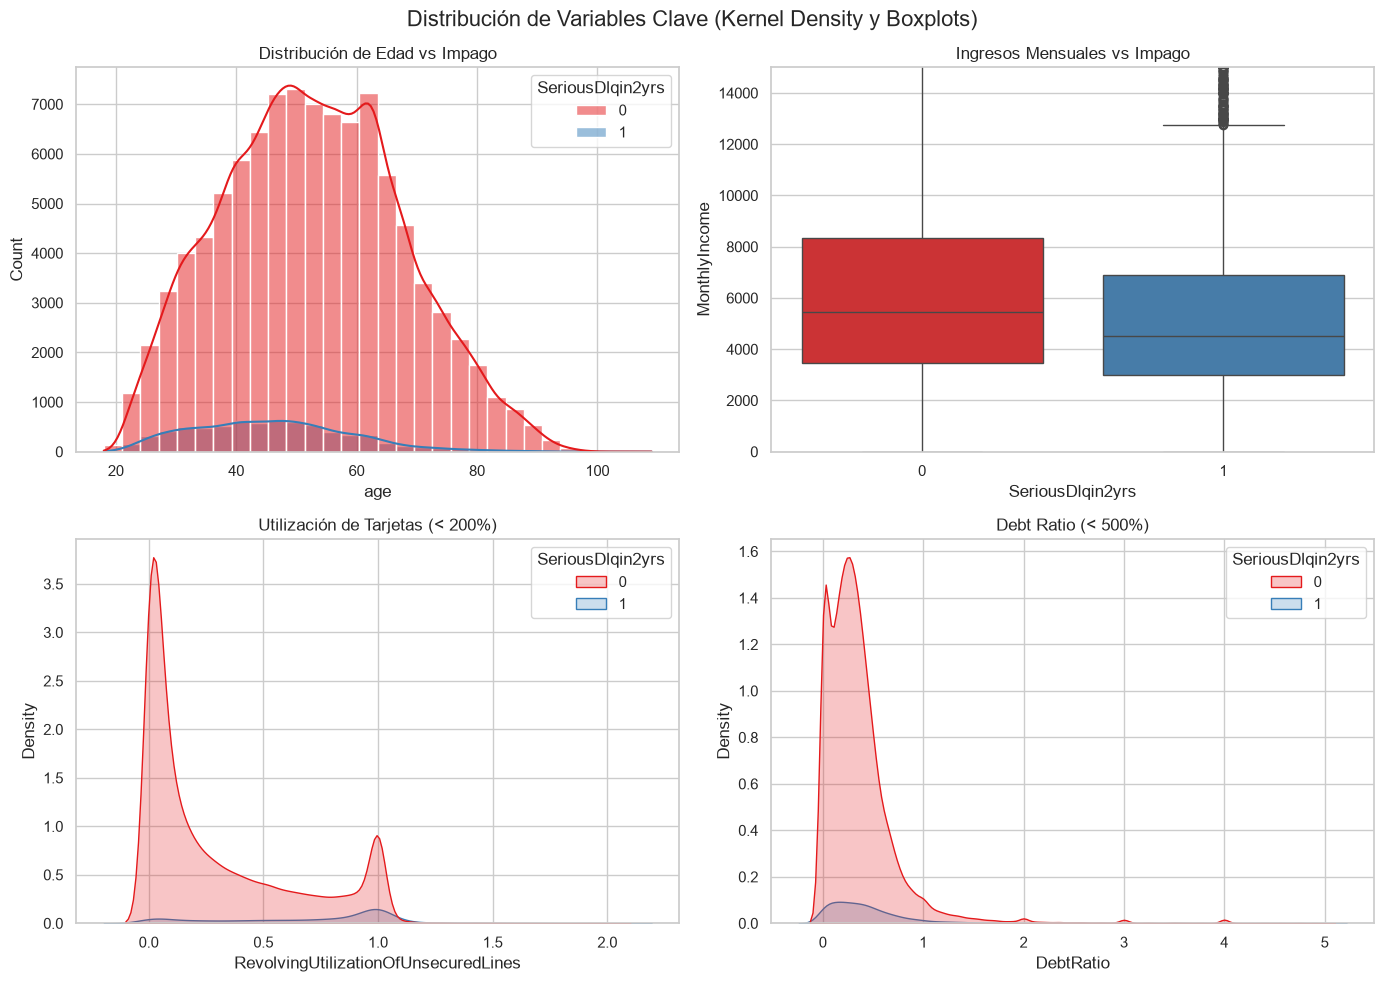

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de Variables Clave (Kernel Density y Boxplots)', fontsize=16)

# Histograma de Edad por clase
sns.histplot(data=df, x='age', hue='SeriousDlqin2yrs', kde=True, ax=axes[0,0], palette='Set1', bins=30)
axes[0,0].set_title('Distribución de Edad vs Impago')

# Boxplot de Ingresos Mensuales (Limitamos el eje Y para que los outliers no aplasten la gráfica)
sns.boxplot(data=df, x='SeriousDlqin2yrs', y='MonthlyIncome', ax=axes[0,1], palette='Set1')
axes[0,1].set_title('Ingresos Mensuales vs Impago')
axes[0,1].set_ylim(0, 15000) 

# Utilización de Línea de Crédito
sns.kdeplot(data=df[df['RevolvingUtilizationOfUnsecuredLines'] < 2], x='RevolvingUtilizationOfUnsecuredLines', hue='SeriousDlqin2yrs', ax=axes[1,0], fill=True, palette='Set1')
axes[1,0].set_title('Utilización de Tarjetas (< 200%)')

# Distribución de Carga de Deuda (DebtRatio)
sns.kdeplot(data=df[df['DebtRatio'] < 5], x='DebtRatio', hue='SeriousDlqin2yrs', ax=axes[1,1], fill=True, palette='Set1')
axes[1,1].set_title('Debt Ratio (< 500%)')

plt.tight_layout()
plt.show()

### 2.3 Tratamiento de Outliers Específicos (Conocimiento de Negocio)

In [5]:
cols_retrasos = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

for col in cols_retrasos:
    # Los valores 96/98 son códigos de error bancario ("dato desconocido"), no impagos reales.
    # Los sustituimos por el máximo valor "real" observado (< 96) para no distorsionar el modelo.
    max_real = df[df[col] < 96][col].max()
    df.loc[df[col] >= 96, col] = max_real

print("Valores máximos tras winsorización:\n", df[cols_retrasos].max())


Valores máximos tras winsorización:
 NumberOfTime30-59DaysPastDueNotWorse    12
NumberOfTime60-89DaysPastDueNotWorse     8
NumberOfTimes90DaysLate                 15
dtype: int64


En este dataset histórico existe una anomalía conocida: Valores de 96 y 98 en las variables de "días de retraso" (30-59Days, 60-89Days, 90DaysLate). Nadie se retrasa "98 veces" en dos años, esto suele ser un código de error del sistema bancario que indica "Dato desconocido / Cliente no rastreable".
Debemos corregir esto para que el modelo no lo interprete como 98 impagos literales.

### 2.4 Matriz de Correlación

Comprobamos si hay variables redundantes. La multicolinealidad afecta negativamente a los modelos lineales como la Regresión Logística de nuestro MAB.

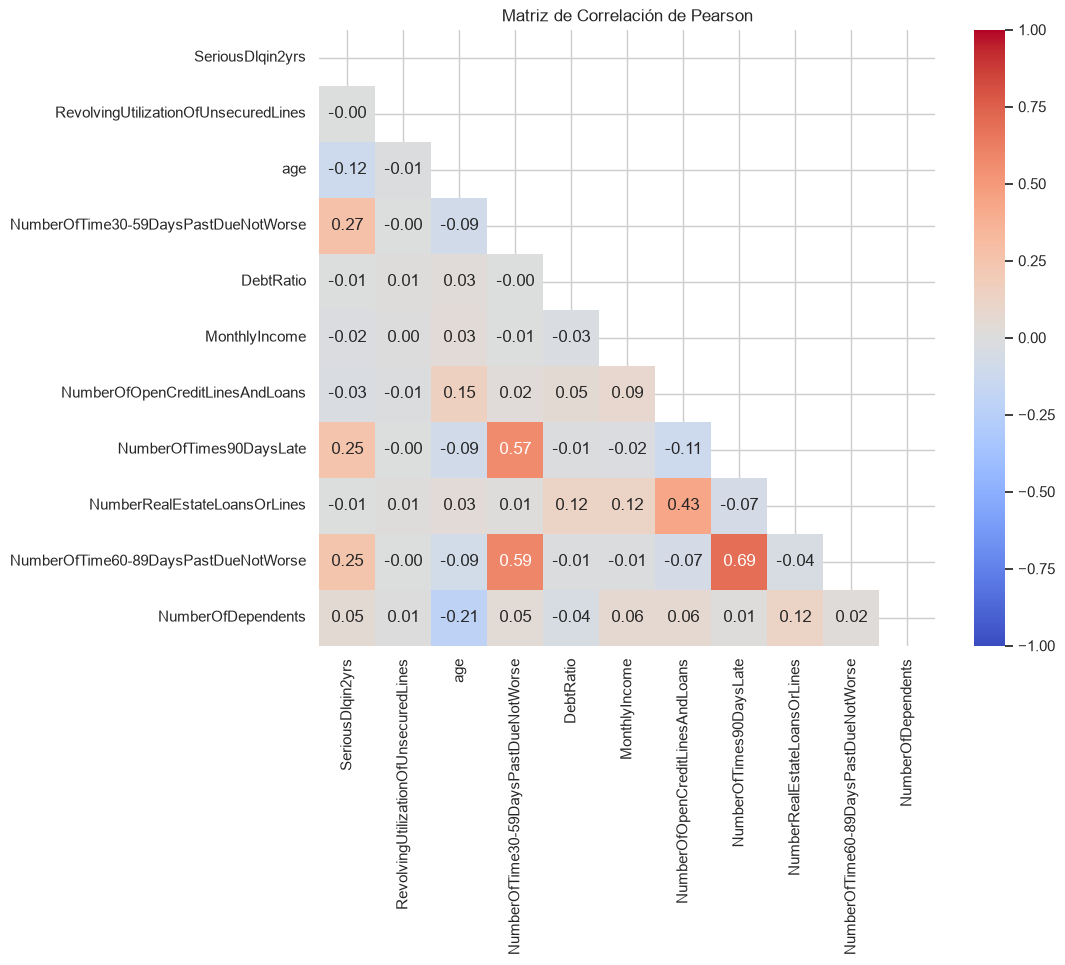

In [6]:
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Matriz de Correlación de Pearson')
plt.show()

### 2.5 Tratamiento Avanzado de Valores Nulos (Ingresos y Dependientes)

En lugar de simplemente borrar los nulos, aplicaremos la estrategia de "Imputación con Variables Indicadoras (Flags)".

Como discutimos, el hecho de que un cliente no declare sus ingresos puede ser un indicador fuerte de riesgo. Vamos a asignar la mediana de ingresos a los nulos (para no desestabilizar el modelo matemáticamente), pero crearemos una columna binaria indicando que ese valor es inventado.

In [7]:
# 1. Crear Flags binarios
df['MonthlyIncome_is_missing'] = df['MonthlyIncome'].isnull().astype(int)
df['NumberOfDependents_is_missing'] = df['NumberOfDependents'].isnull().astype(int)

# 2. Imputación de nulos (Mediana para ingresos, Moda para dependientes)
median_income = df['MonthlyIncome'].median()
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(median_income)

mode_dependents = df['NumberOfDependents'].mode()[0]
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(mode_dependents)

print("Nulos restantes tras la imputación:\n", df.isnull().sum().max() == 0)


Nulos restantes tras la imputación:
 True


### 2.6 División y Estandarización de Datos

Como utilizaremos modelos basados en distancias/gradientes (Regresión Logística para el Bandido Multibrazo), la estandarización (Z-score) es obligatoria. Esto escalará variables enormes como MonthlyIncome y pequeñas como NumberOfDependents a la misma escala métrica (media 0, varianza 1).

Nota metodológica: El escalador (StandardScaler) se ajusta fit SOLO en el set de entrenamiento para evitar el Data Leakage desde el futuro (Validación).

In [8]:
# Separar características de la variable objetivo
X = df.drop(columns=['SeriousDlqin2yrs'])
y = df['SeriousDlqin2yrs']

# División Estratificada 70% Train / 30% Validacion
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# Inicializar y aplicar StandardScaler
scaler = StandardScaler()

# Ajustamos (fit) solo en Train, y transformamos (transform) Train y Val
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)

print("Datos listos para modelado. Ejemplo de Train Scaled:")
display(X_train_scaled.head(3))

Datos listos para modelado. Ejemplo de Train Scaled:


,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_is_missing,NumberOfDependents_is_missing
32259,-0.023271,-0.083617,-0.313664,-0.237608,-0.047267,-0.863682,-0.146606,-0.895518,-0.166406,2.052754,-0.499915,-0.163997
99796,-0.025980,0.390501,-0.313664,0.673328,-0.094016,4.208679,-0.146606,-0.895518,-0.166406,0.241761,2.000340,-0.163997
100887,-0.022234,1.609664,-0.313664,-0.237735,-0.094016,-1.448954,-0.146606,-0.895518,-0.166406,-0.663735,2.000340,6.097690


### 3. Fase de Modelado y Optimización de Costes

Tras haber limpiado, imputado y estandarizado los datos en la fase de preprocesamiento, disponemos de X_train_scaled, X_val_scaled, y_train y y_val.
A continuación, entrenaremos y compararemos dos enfoques distintos bajo dos escenarios de costes.

#### Modelos Supervisados (XGBoost / LightGBM)

Utilizaremos LightGBM, un algoritmo basado en árboles extremadamente eficiente para datos tabulares financieros.

#### Enfoque Dinámico: Multi-Armed Bandit (MAB) Contextual

A diferencia de un modelo estático, el MAB aprende progresivamente. Si decide "Denegar" un crédito, nunca sabrá si el cliente habría pagado (censura de datos). Hemos incluido un control if len(np.unique(self.y_meta)) > 1 para evitar bloqueos si el modelo encuentra secuencias prolongadas de clientes perfectos (pura clase 0).

In [9]:

# ==========================================
# 0. FUNCIONES AUXILIARES Y CLASES MAB
# ==========================================
def calcular_coste_total(y_real, y_pred, coste_fp, coste_fn):
    fps = np.sum((y_real == 0) & (y_pred == 1))
    fns = np.sum((y_real == 1) & (y_pred == 0))
    coste = (fps * coste_fp) + (fns * coste_fn)
    return coste, fps, fns

class ContextualCreditBandit:
    def __init__(self, epsilon=0.10, coste_fp=1, coste_fn=1):
        self.epsilon = epsilon
        self.coste_fp = coste_fp
        self.coste_fn = coste_fn
        self.model_cost_approve = LogisticRegression(warm_start=True, max_iter=200)
        self.initialized = False
        self.X_meta = None
        self.y_meta = None
        
    def fit_initial(self, X_init, y_init):
        self.X_meta = np.array(X_init)
        self.y_meta = np.array(y_init)
        if len(np.unique(self.y_meta)) > 1:
            self.model_cost_approve.fit(self.X_meta, self.y_meta)
            self.initialized = True
        
    def predict_decision(self, X_individual):
        if not self.initialized or np.random.rand() < self.epsilon:
            return np.random.choice([0, 1])
        else:
            prob_default = self.model_cost_approve.predict_proba(X_individual)[0, 1]
            coste_esperado_conceder = prob_default * self.coste_fn
            coste_esperado_denegar = (1 - prob_default) * self.coste_fp
            return 1 if coste_esperado_conceder < coste_esperado_denegar else 0

    def update_policy(self, X_step, y_step):
        if self.X_meta is None:
            self.X_meta = np.array(X_step)
            self.y_meta = np.array([y_step])
        else:
            self.X_meta = np.vstack([self.X_meta, X_step])
            self.y_meta = np.append(self.y_meta, y_step)
            
        if len(np.unique(self.y_meta)) > 1:
            self.model_cost_approve.fit(self.X_meta, self.y_meta)
            self.initialized = True

def simular_mab(X_data, y_data, coste_fp, coste_fn):
    np.random.seed(42)
    bandit = ContextualCreditBandit(epsilon=0.1, coste_fp=coste_fp, coste_fn=coste_fn)
    bandit.fit_initial(X_data.iloc[:100], y_data.iloc[:100])
    
    decisiones = []
    y_reales_eval = []
    costes_acumulados_promedio = [] # Variable para almacenar el historial de coste
    coste_acumulado = 0
    
    for i in range(100, len(X_data)):
        x_instancia = X_data.iloc[[i]]
        y_instancia = y_data.iloc[i]
        
        accion = bandit.predict_decision(x_instancia)
        decisiones.append(accion)
        y_reales_eval.append(y_instancia)
        
        if accion == 1:
            bandit.update_policy(x_instancia, y_instancia)
            
        # Seguimiento del coste para la gráfica de convergencia
        pred_para_coste = 1 if accion == 0 else 0
        if pred_para_coste == 1 and y_instancia == 0:
            coste_acumulado += coste_fp
        elif pred_para_coste == 0 and y_instancia == 1:
            coste_acumulado += coste_fn
            
        costes_acumulados_promedio.append(coste_acumulado / (i - 99))
            
    preds_mab = np.array([1 if d == 0 else 0 for d in decisiones])
    coste_total, fp, fn = calcular_coste_total(np.array(y_reales_eval), preds_mab, coste_fp, coste_fn)
    
    # ATENCIÓN: Aquí devolvemos exactamente los 5 valores esperados
    return coste_total, fp, fn, bandit, costes_acumulados_promedio 


In [10]:
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV



--- Entrenando Modelo 1 (Supervisado - Coste 1:1) ---
[LightGBM] [Info] Number of positive: 3276, number of negative: 45724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001356 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 966
[LightGBM] [Info] Number of data points in the train set: 49000, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.066857 -> initscore=-2.636000
[LightGBM] [Info] Start training from score -2.636000
[LightGBM] [Info] Number of positive: 3275, number of negative: 45725
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001116 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 965
[LightGBM] [Info] Number of data points in the train set: 49

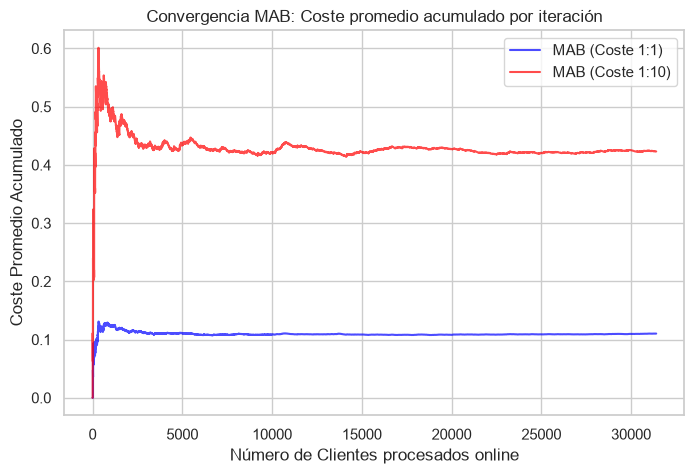


--- Resumen de Costes en Validación ---


,Modelo,Coste_Validacion
0,M1_Supervisado_1:1,2017
1,M2_Bandit_1:1,3463
2,M3_Supervisado_1:10,10499
3,M4_Bandit_1:10,13285



--- Cargando Datos de Producción ---

Ganador 1:1 (M1_Supervisado_1:1) exportado a 'cs_produccion1.csv'.
Ganador 1:10 (M3_Supervisado_1:10) exportado a 'cs_produccion2.csv'.


In [11]:
# ==========================================
# 3. MODELADO Y GRÁFICAS DE CONVERGENCIA
# ==========================================
resultados_costes = {}

# --- MODELO 1: Supervisado Coste 1:1 ---
# Coste FP = Coste FN = 1 -> escenario simétrico, sin rebalanceo de clases.
# El umbral óptimo de Bayes es 1/(1+1) = 0.5, igual que el umbral por defecto de predict().
print("\n--- Entrenando Modelo 1 (Supervisado - Coste 1:1) ---")
base_model_1 = LGBMClassifier(n_estimators=300, random_state=42)
calibrated_model_1 = CalibratedClassifierCV(estimator=base_model_1, method='isotonic', cv=3)
calibrated_model_1.fit(X_train_scaled, y_train)

umbral_optimo_m1 = 1 / (1 + 1)  # 0.5
prob_impago_val_1 = calibrated_model_1.predict_proba(X_val_scaled)[:, 1]
preds_sup_1 = (prob_impago_val_1 >= umbral_optimo_m1).astype(int)

coste_m1, fp_m1, fn_m1 = calcular_coste_total(y_val, preds_sup_1, 1, 1)
resultados_costes['M1_Supervisado_1:1'] = {'coste': coste_m1, 'modelo': calibrated_model_1, 'umbral': umbral_optimo_m1}
print(f"Modelo 1 -> Umbral óptimo: {umbral_optimo_m1:.4f} | Coste Total Validación: {coste_m1} | FP: {fp_m1} | FN: {fn_m1}")

# --- MODELO 2: MAB Coste 1:1 ---
print("\n--- Ejecutando Simulación Modelo 2 (MAB - Coste 1:1) ---")
coste_m2, fp_m2, fn_m2, bandit_m2, conv_m2 = simular_mab(X_val_scaled, y_val, 1, 1)
resultados_costes['M2_Bandit_1:1'] = {'coste': coste_m2, 'modelo': bandit_m2}
print(f"Modelo 2 -> Coste Total Validación: {coste_m2} | FP: {fp_m2} | FN: {fn_m2}")

# --- MODELO 3: Supervisado Coste 1:10 ---
print("\n--- Entrenando Modelo 3 (Supervisado - Coste 1:10) ---")
base_model_3 = LGBMClassifier(n_estimators=100, random_state=42)
calibrated_model_3 = CalibratedClassifierCV(estimator=base_model_3, method='isotonic', cv=3)
calibrated_model_3.fit(X_train_scaled, y_train)

umbral_optimo_m3 = 1 / (1 + 10)  # 0.0909
prob_impago_val_3 = calibrated_model_3.predict_proba(X_val_scaled)[:, 1]
preds_sup_3 = (prob_impago_val_3 >= umbral_optimo_m3).astype(int)

coste_m3, fp_m3, fn_m3 = calcular_coste_total(y_val, preds_sup_3, 1, 10)
resultados_costes['M3_Supervisado_1:10'] = {'coste': coste_m3, 'modelo': calibrated_model_3, 'umbral': umbral_optimo_m3}
print(f"Modelo 3 -> Umbral óptimo: {umbral_optimo_m3:.4f} | Coste Validación: {coste_m3} | FP: {fp_m3} | FN: {fn_m3}")

# --- MODELO 4: MAB Coste 1:10 ---
print("\n--- Ejecutando Simulación Modelo 4 (MAB - Coste 1:10) ---")
coste_m4, fp_m4, fn_m4, bandit_m4, conv_m4 = simular_mab(X_val_scaled, y_val, 1, 10)
resultados_costes['M4_Bandit_1:10'] = {'coste': coste_m4, 'modelo': bandit_m4}
print(f"Modelo 4 -> Coste Total Validación: {coste_m4} | FP: {fp_m4} | FN: {fn_m4}")

# GRÁFICA: Convergencia de los Modelos MAB
plt.figure(figsize=(8, 5))
plt.plot(conv_m2, label='MAB (Coste 1:1)', color='blue', alpha=0.7)
plt.plot(conv_m4, label='MAB (Coste 1:10)', color='red', alpha=0.7)
plt.title('Convergencia MAB: Coste promedio acumulado por iteración')
plt.xlabel('Número de Clientes procesados online')
plt.ylabel('Coste Promedio Acumulado')
plt.legend()
plt.show()

# TABLA RESUMEN DE COSTES
print("\n--- Resumen de Costes en Validación ---")
tabla_resumen = pd.DataFrame({
    'Modelo': list(resultados_costes.keys()),
    'Coste_Validacion': [v['coste'] for v in resultados_costes.values()]
})
display(tabla_resumen)

# ==========================================
# 4. CARGA DE PRODUCCIÓN (TEST) Y EXPORTACIÓN
# ==========================================
print("\n--- Cargando Datos de Producción ---")
# Cargar fichero real de producción
df_prod = pd.read_csv('cs_produccion.csv', index_col=0)

if 'SeriousDlqin2yrs' in df_prod.columns:
    df_prod = df_prod.drop(columns=['SeriousDlqin2yrs'])

# Aplicar las mismas reglas de limpieza que en construcción
df_prod.loc[df_prod['age'] <= 18, 'age'] = 18
for col in cols_retrasos:
    df_prod.loc[df_prod[col] >= 96, col] = max_real

# Crear Flags e Imputar usando las métricas calculadas en el Entrenamiento (nunca recalcular en producción)
df_prod['MonthlyIncome_is_missing'] = df_prod['MonthlyIncome'].isnull().astype(int)
df_prod['NumberOfDependents_is_missing'] = df_prod['NumberOfDependents'].isnull().astype(int)

df_prod['MonthlyIncome'] = df_prod['MonthlyIncome'].fillna(median_income)
df_prod['NumberOfDependents'] = df_prod['NumberOfDependents'].fillna(mode_dependents)

# Estandarización usando el scaler ya ajustado en train (.transform, NUNCA .fit_transform)
X_produccion_scaled = pd.DataFrame(scaler.transform(df_prod), columns=df_prod.columns, index=df_prod.index)

# Función de Inferencia
def predecir_produccion(dict_ganador, X_prod):
    modelo = dict_ganador['modelo']
    if isinstance(modelo, ContextualCreditBandit):
        decisiones = [modelo.predict_decision(X_prod.iloc[[i]]) for i in range(len(X_prod))]
        return np.array([1 if d == 0 else 0 for d in decisiones])
    else:
        probs = modelo.predict_proba(X_prod)[:, 1]
        return (probs >= dict_ganador['umbral']).astype(int)

# ---- EXPORTACIÓN ESCENARIO 1 (Coste 1:1) ----
ganador_1_1 = 'M1_Supervisado_1:1' if resultados_costes['M1_Supervisado_1:1']['coste'] <= resultados_costes['M2_Bandit_1:1']['coste'] else 'M2_Bandit_1:1'
pred_1 = predecir_produccion(resultados_costes[ganador_1_1], X_produccion_scaled)

df_out_1 = pd.DataFrame({'Id': X_produccion_scaled.index, 'Prediction': pred_1})
df_out_1.to_csv('cs_produccion1.csv', index=False)
print(f"\nGanador 1:1 ({ganador_1_1}) exportado a 'cs_produccion1.csv'.")

# ---- EXPORTACIÓN ESCENARIO 2 (Coste 1:10) ----
ganador_1_10 = 'M3_Supervisado_1:10' if resultados_costes['M3_Supervisado_1:10']['coste'] <= resultados_costes['M4_Bandit_1:10']['coste'] else 'M4_Bandit_1:10'
pred_2 = predecir_produccion(resultados_costes[ganador_1_10], X_produccion_scaled)

df_out_2 = pd.DataFrame({'Id': X_produccion_scaled.index, 'Prediction': pred_2})
df_out_2.to_csv('cs_produccion2.csv', index=False)
print(f"Ganador 1:10 ({ganador_1_10}) exportado a 'cs_produccion2.csv'.")


### 4. Auditoría y Explicabilidad (XAI)

Una vez seleccionado el modelo ganador en cada escenario de coste, es imprescindible auditar su comportamiento antes de ponerlo en producción. Un modelo de concesión de crédito afecta directamente a las personas, por lo que necesitamos poder explicar sus decisiones tanto a nivel agregado (qué variables pesan más en general) como a nivel individual (por qué se ha denegado un crédito concreto), y comprobar que su lógica es razonable y no se apoya en atajos espurios.

Nos centramos en el **modelo ganador del escenario 1:10** (`M3_Supervisado_1:10`), por ser el más relevante desde el punto de vista de negocio: penaliza fuertemente el impago (Coste FN = 10), que es la situación real que un banco quiere evitar. Donde aporte contraste, comparamos también con el modelo del escenario 1:1.

#### 4.1 Modelo subrogado (surrogate) con reglas interpretables

Entrenamos un **árbol de decisión poco profundo** para que aprenda a imitar las predicciones del modelo caja negra (LightGBM calibrado). El árbol no se entrena contra la variable real `y`, sino contra las **predicciones del modelo ganador**, de forma que sus reglas describen *cómo razona el modelo*, no cómo es la realidad. Limitamos la profundidad (`max_depth=4`) para que las reglas sean legibles por una persona no técnica (ej. un gestor de la oficina que tiene que justificar una denegación).

Fidelidad del subrogado respecto al modelo caja negra (accuracy de imitación): 0.9289


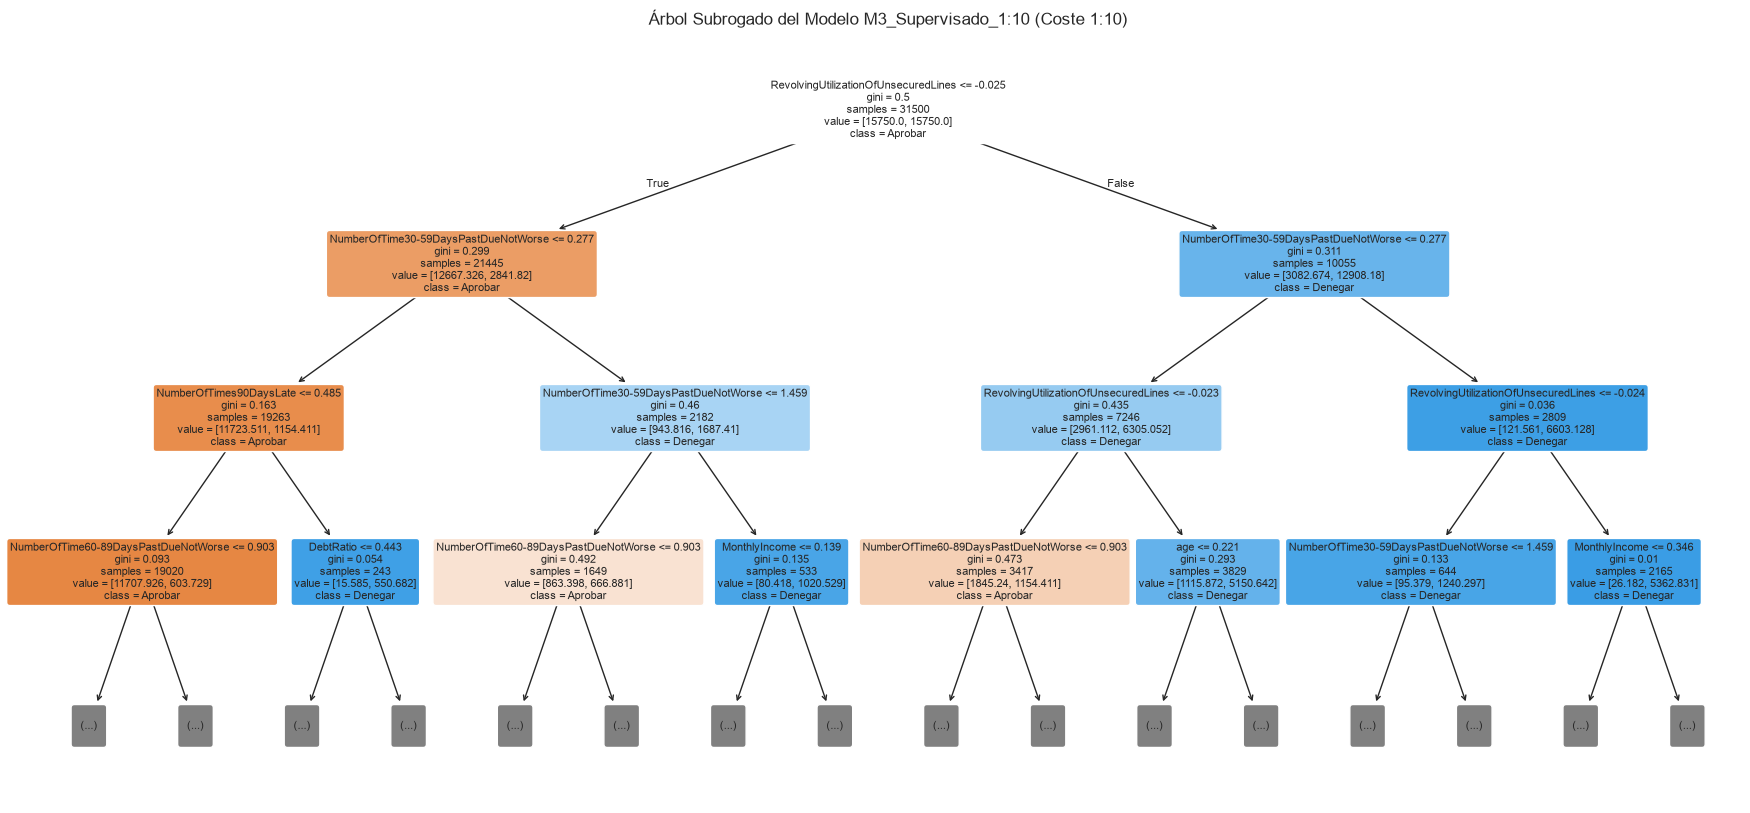


Reglas en formato texto:

|--- RevolvingUtilizationOfUnsecuredLines <= -0.02
|   |--- NumberOfTime30-59DaysPastDueNotWorse <= 0.28
|   |   |--- NumberOfTimes90DaysLate <= 0.49
|   |   |   |--- NumberOfTime60-89DaysPastDueNotWorse <= 0.90
|   |   |   |   |--- class: 0
|   |   |   |--- NumberOfTime60-89DaysPastDueNotWorse >  0.90
|   |   |   |   |--- class: 1
|   |   |--- NumberOfTimes90DaysLate >  0.49
|   |   |   |--- DebtRatio <= 0.44
|   |   |   |   |--- class: 1
|   |   |   |--- DebtRatio >  0.44
|   |   |   |   |--- class: 1
|   |--- NumberOfTime30-59DaysPastDueNotWorse >  0.28
|   |   |--- NumberOfTime30-59DaysPastDueNotWorse <= 1.46
|   |   |   |--- NumberOfTime60-89DaysPastDueNotWorse <= 0.90
|   |   |   |   |--- class: 0
|   |   |   |--- NumberOfTime60-89DaysPastDueNotWorse >  0.90
|   |   |   |   |--- class: 1
|   |   |--- NumberOfTime30-59DaysPastDueNotWorse >  1.46
|   |   |   |--- MonthlyIncome <= 0.14
|   |   |   |   |--- class: 1
|   |   |   |--- MonthlyIncome >  0.14
| 

In [12]:
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

# Modelo ganador del escenario 1:10 (el de mayor relevancia de negocio)
modelo_ganador_1_10 = resultados_costes[ganador_1_10]['modelo']
umbral_ganador_1_10 = resultados_costes[ganador_1_10].get('umbral', 0.5)

# Predicciones del modelo caja negra sobre validación (esto es lo que el subrogado debe imitar)
prob_ganador_val = modelo_ganador_1_10.predict_proba(X_val_scaled)[:, 1]
pred_ganador_val = (prob_ganador_val >= umbral_ganador_1_10).astype(int)

# Entrenamos el árbol subrogado para que replique las decisiones del modelo, no la realidad
surrogate_tree = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')
surrogate_tree.fit(X_val_scaled, pred_ganador_val)

fidelidad = surrogate_tree.score(X_val_scaled, pred_ganador_val)
print(f"Fidelidad del subrogado respecto al modelo caja negra (accuracy de imitación): {fidelidad:.4f}")

plt.figure(figsize=(22, 10))
plot_tree(
    surrogate_tree,
    feature_names=X_val_scaled.columns,
    class_names=['Aprobar', 'Denegar'],
    filled=True, rounded=True, fontsize=8, max_depth=3
)
plt.title(f"Árbol Subrogado del Modelo {ganador_1_10} (Coste 1:10)")
plt.show()

print("\nReglas en formato texto:\n")
print(export_text(surrogate_tree, feature_names=list(X_val_scaled.columns)))

**Lectura del subrogado**: la fidelidad indica en qué medida las reglas simples del árbol reproducen las decisiones del modelo real; una fidelidad alta (>90%) significa que el árbol es un resumen fiable del comportamiento del modelo, aunque este siga siendo el que se usa en producción (el subrogado es solo una herramienta de explicación, no reemplaza al modelo). Las variables que aparecen en los primeros niveles del árbol (típicamente `NumberOfTimes90DaysLate`, `RevolvingUtilizationOfUnsecuredLines` y `age`) son las que el modelo usa como criterio principal de corte.

#### 4.2 Análisis de contrafactuales

Cuando un cliente pregunta *"¿por qué me han denegado el crédito?"*, la respuesta más útil no es la importancia de variables en abstracto, sino un **contrafactual accionable**: el cambio mínimo en su perfil que habría bastado para obtener la aprobación. Implementamos una búsqueda de contrafactuales por **perturbación greedy**: para cada instancia, se prueban variaciones razonables (dentro de un rango realista) de las variables más influyentes, y se busca la combinación de menor coste (menor distancia al original) que cruza el umbral de decisión.

Aplicamos este análisis a varios clientes de clase real 0 (buen pagador) y clase real 1 (impago), denegados por el modelo, para entender qué información sería razonable comunicarle a cada perfil.

In [13]:
def buscar_contrafactual(modelo, umbral, x_original, feature_names,
                          variables_modificables, n_pasos=20, max_delta_std=1.5):
    """
    Búsqueda greedy de un contrafactual: para cada variable modificable, se prueba
    moverla en pasos discretos (en unidades de desviación estándar, ya que los datos
    están estandarizados) en la dirección que reduce la probabilidad de impago,
    y se aplica el cambio que logra el mayor descenso de probabilidad por unidad de
    distancia recorrida. Se detiene en cuanto la predicción cruza el umbral.
    Limitamos cada desplazamiento a max_delta_std para mantener los cambios dentro
    de un rango realista (evitar proponer, p.ej., ingresos negativos).
    """
    x_cf = x_original.copy()
    prob_inicial = modelo.predict_proba(x_cf)[:, 1][0]

    if prob_inicial < umbral:
        return x_cf, prob_inicial, []  # ya se aprobaría, no hace falta contrafactual

    cambios_aplicados = []
    pasos_delta = np.linspace(-max_delta_std, max_delta_std, n_pasos)
    variables_ya_tocadas = set()

    for _ in range(len(variables_modificables)):
        mejor_mejora, mejor_var, mejor_valor_previo, mejor_valor, mejor_prob = 0, None, None, None, None
        prob_actual = modelo.predict_proba(x_cf)[:, 1][0]

        for var in variables_modificables:
            valor_previo = x_cf[var].values[0]
            for delta in pasos_delta:
                candidato = x_cf.copy()
                candidato[var] = valor_previo + delta
                prob_candidato = modelo.predict_proba(candidato)[:, 1][0]
                mejora = prob_actual - prob_candidato
                # Preferimos mejoras grandes con desplazamientos pequeños
                if prob_candidato < prob_actual and mejora > mejor_mejora:
                    mejor_mejora = mejora
                    mejor_var = var
                    mejor_valor_previo = valor_previo
                    mejor_valor = valor_previo + delta
                    mejor_prob = prob_candidato

        if mejor_var is None:
            break

        x_cf[mejor_var] = mejor_valor
        variables_ya_tocadas.add(mejor_var)
        # Guardamos (variable, valor_antes_de_este_paso, valor_despues) para que el log
        # de cambios sea correcto incluso si una misma variable se ajusta en varios pasos.
        cambios_aplicados.append((mejor_var, mejor_valor_previo, mejor_valor))

        if mejor_prob < umbral:
            break

    prob_final = modelo.predict_proba(x_cf)[:, 1][0]
    return x_cf, prob_final, cambios_aplicados


# Variables sobre las que tiene sentido pedirle un cambio a un cliente
# (excluimos age y las flags, que no son "accionables" en el corto plazo)
variables_accionables = [
    'RevolvingUtilizationOfUnsecuredLines', 'NumberOfTime30-59DaysPastDueNotWorse',
    'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines',
    'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents'
]

# Seleccionamos ejemplos de clase real 0 y clase real 1 denegados por el modelo
val_idx_denegados_clase0 = X_val_scaled[(y_val.values == 0) & (pred_ganador_val == 1)].index[:2]
val_idx_denegados_clase1 = X_val_scaled[(y_val.values == 1) & (pred_ganador_val == 1)].index[:2]

ejemplos_cf = list(val_idx_denegados_clase0) + list(val_idx_denegados_clase1)

for idx in ejemplos_cf:
    x0 = X_val_scaled.loc[[idx]]
    clase_real = y_val.loc[idx]
    x_cf, prob_final, cambios = buscar_contrafactual(
        modelo_ganador_1_10, umbral_ganador_1_10, x0,
        X_val_scaled.columns, variables_accionables
    )
    prob_orig = modelo_ganador_1_10.predict_proba(x0)[:, 1][0]
    print(f"\n=== Cliente idx={idx} (clase real={clase_real}) ===")
    print(f"Prob. impago original: {prob_orig:.3f} (umbral={umbral_ganador_1_10:.3f}) -> Denegado")
    if not cambios:
        print("No se encontró un contrafactual razonable dentro del rango explorado (denegación robusta).")
    else:
        print(f"Prob. impago tras cambios propuestos: {prob_final:.3f} -> {'Aprobado' if prob_final < umbral_ganador_1_10 else 'Sigue denegado'}")
        print("Cambios sugeridos (en escala estandarizada, variable: antes -> después):")
        for var, valor_antes, valor_despues in cambios:
            print(f"  - {var}: {valor_antes:.2f} -> {valor_despues:.2f}")


=== Cliente idx=53771 (clase real=0) ===
Prob. impago original: 0.127 (umbral=0.091) -> Denegado
Prob. impago tras cambios propuestos: 0.052 -> Aprobado
Cambios sugeridos (en escala estandarizada, variable: antes -> después):
  - MonthlyIncome: -0.55 -> -2.05

=== Cliente idx=103416 (clase real=0) ===
Prob. impago original: 0.302 (umbral=0.091) -> Denegado
Prob. impago tras cambios propuestos: 0.075 -> Aprobado
Cambios sugeridos (en escala estandarizada, variable: antes -> después):
  - RevolvingUtilizationOfUnsecuredLines: -0.02 -> -1.52

=== Cliente idx=15985 (clase real=1) ===
Prob. impago original: 0.202 (umbral=0.091) -> Denegado
Prob. impago tras cambios propuestos: 0.083 -> Aprobado
Cambios sugeridos (en escala estandarizada, variable: antes -> después):
  - RevolvingUtilizationOfUnsecuredLines: -0.02 -> -1.52

=== Cliente idx=7773 (clase real=1) ===
Prob. impago original: 0.462 (umbral=0.091) -> Denegado
Prob. impago tras cambios propuestos: 0.195 -> Sigue denegado
Cambios sug

**¿Qué información le damos al cliente?** No debemos comunicar directamente los valores estandarizados ni la probabilidad interna del modelo. Lo accionable y comprensible es el **factor de negocio** detrás de la variable que más ha movido la decisión, por ejemplo: *"reducir el número de líneas de crédito abiertas"*, *"regularizar los pagos con retraso de los últimos meses"* o *"reducir el ratio de deuda sobre ingresos"*. En los casos de clase real 1 (impago) donde no se encuentra un contrafactual razonable, esto es una señal positiva de auditoría: significa que el modelo deniega ese perfil de forma robusta y no por un pequeño matiz arbitrario.

#### 4.3 Análisis SHAP global y local

SHAP (SHapley Additive exPlanations) reparte la predicción de cada instancia entre sus variables de forma consistente con la teoría de juegos. Usamos `TreeExplainer`, diseñado específicamente para modelos de árboles como LightGBM, sobre el **estimador base** dentro de `CalibratedClassifierCV` (la calibración isotónica es un reescalado posterior de las probabilidades y no altera qué variables generan la decisión del árbol).

--- SHAP Global: importancia media de cada variable ---


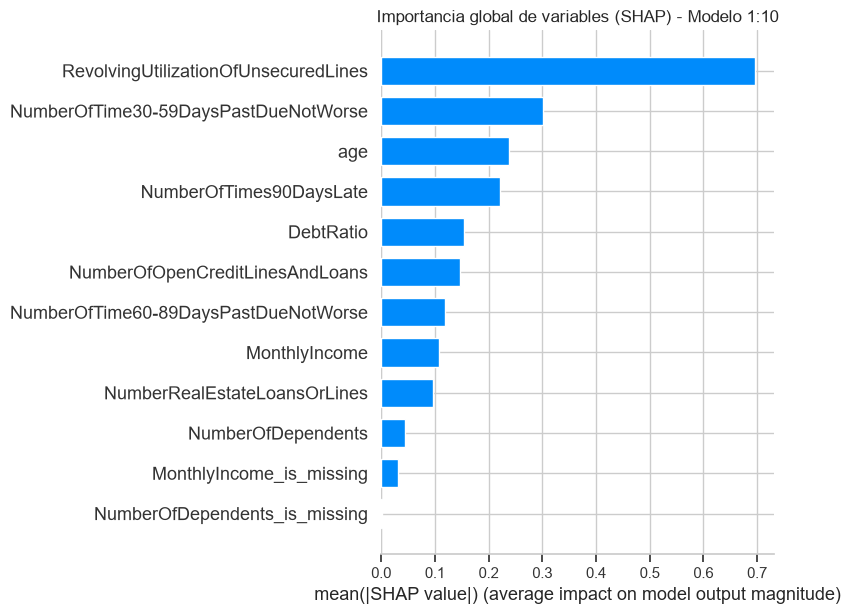

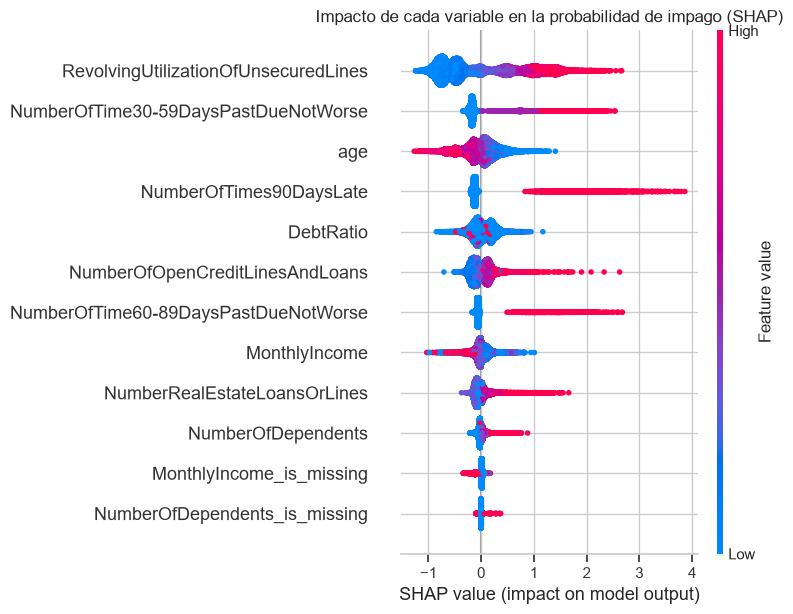

In [14]:
import shap

# Extraemos uno de los estimadores base entrenados dentro del CalibratedClassifierCV
# (cv=3 genera 3 modelos base; usamos el primero como representante para la explicación)
lgbm_base_1_10 = modelo_ganador_1_10.calibrated_classifiers_[0].estimator

explainer = shap.TreeExplainer(lgbm_base_1_10)
shap_values = explainer.shap_values(X_val_scaled)

# Para clasificación binaria, shap_values puede devolver una lista [clase0, clase1] o un array 2D/3D según versión
if isinstance(shap_values, list):
    shap_values_clase1 = shap_values[1]
elif shap_values.ndim == 3:
    shap_values_clase1 = shap_values[:, :, 1]
else:
    shap_values_clase1 = shap_values

# --- SHAP GLOBAL ---
print("--- SHAP Global: importancia media de cada variable ---")
shap.summary_plot(shap_values_clase1, X_val_scaled, plot_type="bar", show=False)
plt.title("Importancia global de variables (SHAP) - Modelo 1:10")
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values_clase1, X_val_scaled, show=False)
plt.title("Impacto de cada variable en la probabilidad de impago (SHAP)")
plt.tight_layout()
plt.show()

**SHAP local**: aplicamos la explicación instancia a instancia sobre los mismos clientes usados en el análisis de contrafactuales, para poder comparar ambas explicaciones (SHAP dice *qué pesó en la decisión*; el contrafactual dice *qué habría que cambiar*).


=== Explicación SHAP local - Cliente idx=53771 (clase real=0) ===


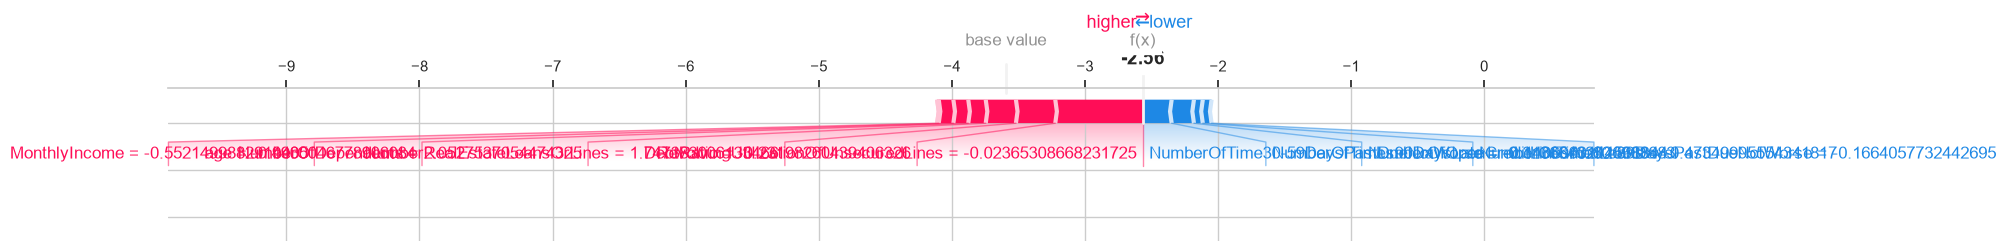


=== Explicación SHAP local - Cliente idx=103416 (clase real=0) ===


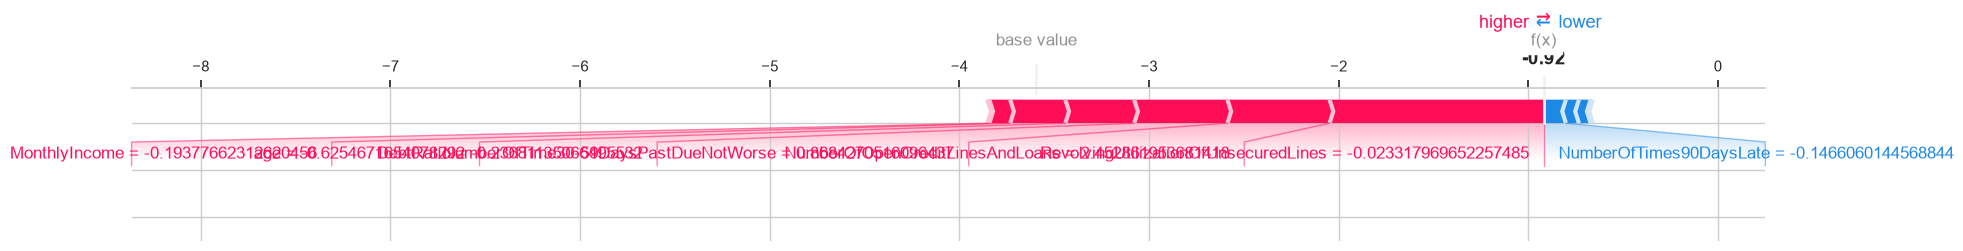


=== Explicación SHAP local - Cliente idx=15985 (clase real=1) ===


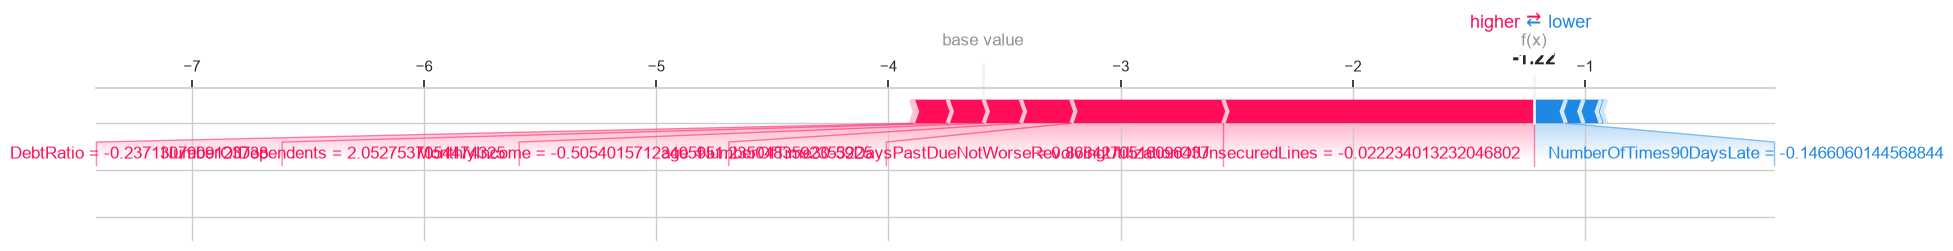


=== Explicación SHAP local - Cliente idx=7773 (clase real=1) ===


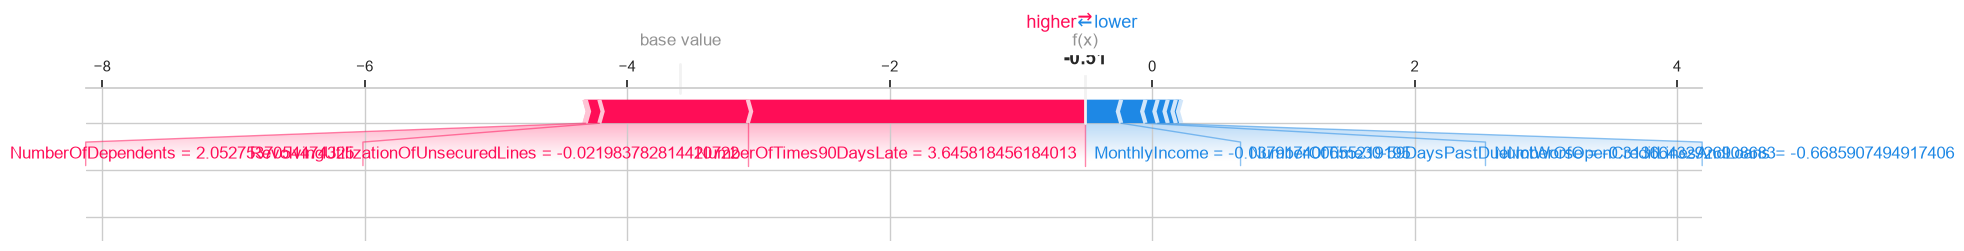

In [15]:
# --- SHAP LOCAL: mismos clientes que en el análisis de contrafactuales ---
expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = expected_value[1] if len(np.atleast_1d(expected_value)) > 1 else expected_value[0]

for idx in ejemplos_cf:
    pos = X_val_scaled.index.get_loc(idx)
    clase_real = y_val.loc[idx]
    print(f"\n=== Explicación SHAP local - Cliente idx={idx} (clase real={clase_real}) ===")
    shap.force_plot(
        expected_value,
        shap_values_clase1[pos, :],
        X_val_scaled.iloc[pos, :],
        matplotlib=True, show=False
    )
    plt.tight_layout()
    plt.show()

**Lectura conjunta**: si las variables con mayor peso SHAP para un cliente coinciden con las que el contrafactual identifica como palanca de cambio, tenemos coherencia entre ambas técnicas y mayor confianza en la explicación que le damos al cliente. Si no coinciden, conviene revisar si el contrafactual está explotando una zona del espacio de variables poco representada en los datos de entrenamiento (extrapolación), lo cual sería una señal de alerta sobre la robustez de la explicación.

#### 4.4 Otra técnica adicional: Partial Dependence Plots (PDP)

Como técnica complementaria, usamos **Partial Dependence Plots** sobre las variables más relevantes según SHAP global. A diferencia de SHAP (que explica instancias concretas), el PDP muestra la relación **marginal media** entre una variable y la probabilidad de impago predicha, manteniendo el resto de variables en su distribución real. Esto permite comprobar si la relación aprendida por el modelo es monótona y tiene sentido de negocio (ej. a más atrasos de pago, mayor riesgo), o si presenta comportamientos contraintuitivos que ameriten revisión.

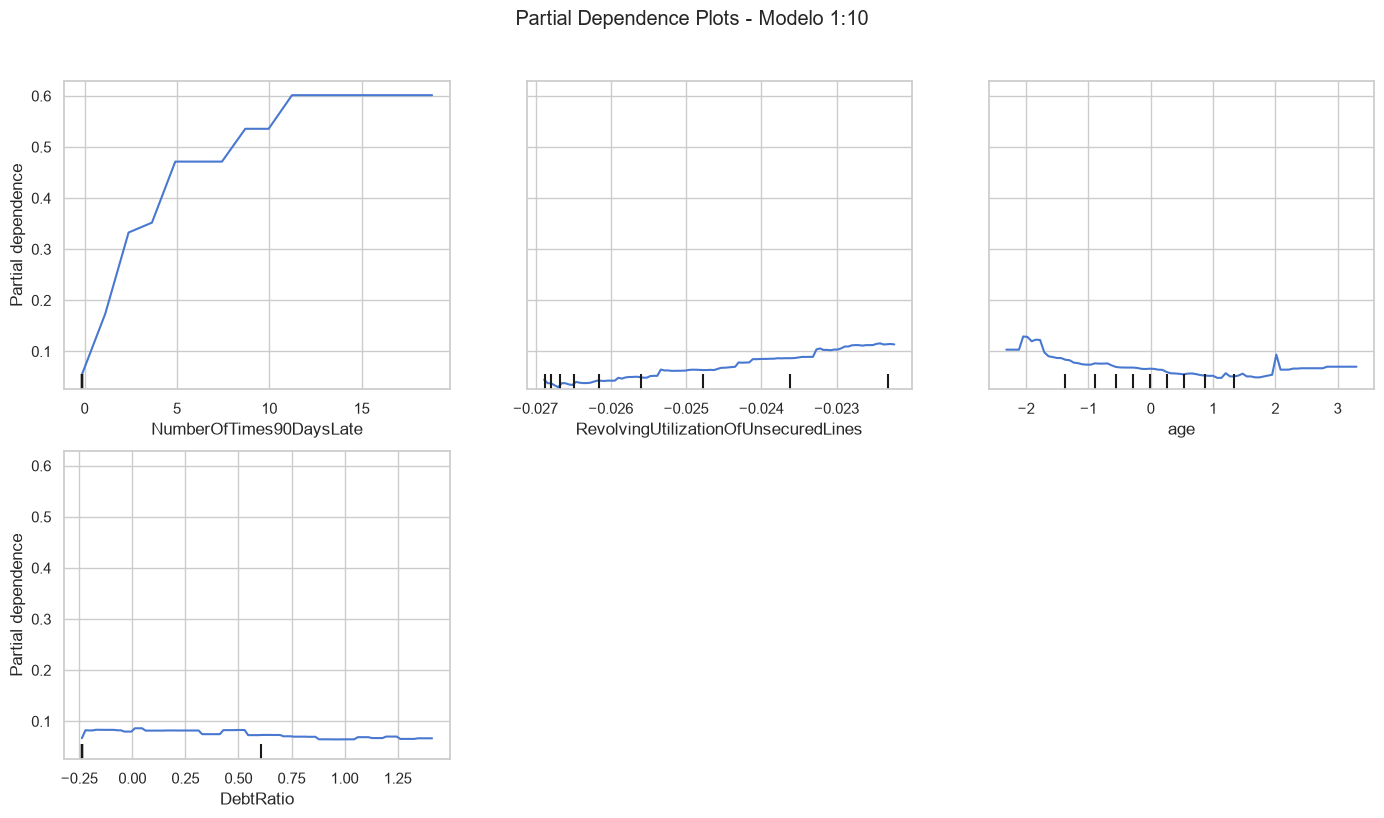

In [16]:
from sklearn.inspection import PartialDependenceDisplay

variables_pdp = [
    'NumberOfTimes90DaysLate', 'RevolvingUtilizationOfUnsecuredLines',
    'age', 'DebtRatio'
]

fig, ax = plt.subplots(figsize=(14, 8))
PartialDependenceDisplay.from_estimator(
    lgbm_base_1_10, X_val_scaled, variables_pdp, ax=ax
)
plt.suptitle("Partial Dependence Plots - Modelo 1:10", y=1.02)
plt.tight_layout()
plt.show()

### 5. Resumen y reflexión final

**Resultados de coste** (ver tabla de la sección 3): el modelo supervisado calibrado supera al Multi-Armed Bandit en ambos escenarios de coste en el conjunto de validación, ya que el MAB paga un coste de exploración (política ε-greedy) y parte de un modelo inicial entrenado con muchos menos datos. El MAB sería más adecuado en un entorno real donde el modelo deba adaptarse de forma continua a *drift* de la población de clientes, algo que un modelo supervisado estático no captura sin reentrenamientos periódicos.

**Efecto del coste asimétrico**: al pasar del escenario 1:1 al escenario 1:10, el umbral óptimo de decisión baja de 0.5 a ≈0.09, lo que hace al modelo mucho más conservador (aumentan los falsos positivos, se reducen drásticamente los falsos negativos). Esto es exactamente el comportamiento esperado cuando aprobar a un cliente que impagará es 10 veces más costoso que denegar por error a un buen pagador.

**Auditoría XAI**: el árbol subrogado confirma que el modelo apoya sus decisiones principalmente en variables de comportamiento de pago (atrasos, utilización de crédito) y no en variables demográficas sensibles de forma aislada, lo cual es una señal positiva desde el punto de vista de equidad. El análisis SHAP global es coherente con las reglas del subrogado, y el análisis local + contrafactuales nos permite dar a cada cliente denegado una explicación accionable y consistente entre ambas técnicas.

**Limitaciones**: el subrogado es una aproximación (fidelidad < 100%) y no debe usarse como el modelo de producción; los contrafactuales generados por búsqueda greedy no garantizan optimalidad global ni verifican que la combinación de cambios sea realista para el cliente (p. ej. combinaciones de variables correlacionadas entre sí); y el PDP asume independencia entre variables, lo cual no siempre se cumple en datos financieros (ej. `DebtRatio` y `MonthlyIncome` están relacionadas).